# Non-Negative Matrix Factorization (NMF) — BBC News

Ce notebook applique NMF au dataset BBC News en suivant le pipeline de la série (prétraitement TF-IDF, split stratifié, tuning de n_components/alpha, évaluation avec ARI/NMI/Silhouette, et visualisation des topics).

In [9]:
# Installer les dépendances si nécessaire (décommentez si requis)
# %pip install -q scikit-learn pandas numpy matplotlib seaborn nltk wordcloud

In [10]:
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
sns.set_theme(style='whitegrid')
np.random.seed(42)
random.seed(42)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\afagn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
# Charger le dataset BBC News depuis le fichier local demandé
dataset_path = Path('D:/100DaysofML/Notebooks/076_Non-Negative_Matrix_Factorization (NMF)/BBC news dataset.csv')
if not dataset_path.exists():
    raise FileNotFoundError(f'Fichier introuvable: {dataset_path}')
# Lecture en considérant qu'il y a parfois une colonne d'index implicite en première position
df = pd.read_csv(dataset_path, index_col=0)
# Normaliser les noms de colonnes
df.columns = [c.strip() for c in df.columns]
# Construire la colonne `text` si nécessaire (la source peut s'appeler 'description')
if 'text' not in df.columns and 'description' in df.columns:
    df['text'] = df['description']
# Les 'tags' représentent exactement les labels — utiliser le premier tag comme label
if 'tags' in df.columns:
    df['label'] = df['tags'].fillna('').apply(lambda s: s.split(',')[0].strip() if str(s).strip() != '' else 'unknown')
elif 'label' not in df.columns:
    raise KeyError("Aucune colonne 'label' trouvée et impossible d'en déduire depuis 'tags'.")
# Supprimer les labels trop rares (<2 occurrences) comme demandé
label_counts = df['label'].value_counts()
rare = label_counts[label_counts < 2].index.tolist()
if len(rare) > 0:
    print('Suppression des labels trop rares (<2 occurrences):', rare)
    df = df[~df['label'].isin(rare)].reset_index(drop=True)
print(df.shape)
display(df.head())
print('Labels restants:', df['label'].unique())
print(df['label'].value_counts())

Suppression des labels trop rares (<2 occurrences): ['athens', 'n hines', 'edinburgh', 'anniversary of the train bombings', 'mr brown', 'icstis', 'melbourne', 'sunderland', 'glaxosmithkline', "the 400th anniversary of guy fawkes' conspiracy", 'alcohol focus scotland', "the net's most iconic companies", 'nintendo', 'rising sun', 'gamer', 'santos', 'belfast', 'goldeneye', 'newcastle', 'las vegas', 'edinburgh city', 'the 20th anniversary of former culture secretary chris smith', 'york', 'the anniversary of the liberation of auschwitz', 'melton mowbray', 'nairobi', 'google', "the california festival's 20th anniversary", 'bbc wales', "the 60th anniversary of the former nazi concentration camp's liberation", 'the 36th anniversary of the line closure', 'birmingham', 'durham', 'norwich', "the musical's fifth anniversary", 'sheffield', 'the times', 'san francisco chronicle', 'zurich', 'hamburg', "the 10th anniversary of cantona's infamous kung-fu kick on crystal palace fan matthew simmons", 'ma

,description,tags,text,label
0,chelsea sack mutu chelsea have sacked adrian ...,"sports, stamford bridge, football association,...",chelsea sack mutu chelsea have sacked adrian ...,sports
1,record fails to lift lacklustre meet yelena i...,"sports, madrid, birmingham, france, scotland, ...",record fails to lift lacklustre meet yelena i...,sports
2,edu describes tunnel fracas arsenals edu has ...,"sports, derby, brazil, tunnel fracasedu, food,...",edu describes tunnel fracas arsenals edu has ...,sports
3,ogara revels in ireland victory ireland flyha...,"sports, bbc, united kingdom, ireland, brian o'...",ogara revels in ireland victory ireland flyha...,sports
4,unclear future for striker baros liverpool fo...,"sports, liverpool, daily sport, millennium sta...",unclear future for striker baros liverpool fo...,sports


Labels restants: ['sports' 'education' 'human interest' 'unknown' 'hospitality' 'politics'
 'mps' 'business' 'disaster' 'environment' 'social issues' 'bbc' 'law'
 'united kingdom' 'london' 'health' 'war' 'labor' 'religion' 'bath'
 'technology' 'crystal cruises' 'entertainment'
 'the 10th anniversary of the pc pro awards' 'sony' 'pew' 'the star'
 'merit-free heavy metal soundtrack' 'capgemini' 'exposition' 'iraq'
 'new york' 'jedi' 'hewlett packard' 'amazon.com'
 'the uk are celebrating their 20th anniversary' 'washington' 'scotland'
 'beijing'
 'the 50th anniversary of the fender stratocaster guitar in london in september'
 "the 70th anniversary of presley's birth" 'dublin' 'istanbul' 'rome'
 'brussels']
label
sports                                                                           473
entertainment                                                                    413
business                                                                         399
technology               

In [12]:
# Split stratifié train / val / test (70 / 15 / 15)
# Les labels rares ont déjà été supprimés lors du chargement (labels <2 supprimés).
# Maintenant on peut split stratifié
X = df['text'].values
y = df['label'].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
# Essayer un split stratifié sur le set temporaire; si la distribution est trop faible pour certaines classes,
# effectuer un split aléatoire 50/50 en fallback (préserver train stratifié).
try:
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
except ValueError as e:
    print('Warning: stratified val/test split failed:', e)
    print('Falling back to non-stratified 50/50 split on temp set')
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=None)
print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

Falling back to non-stratified 50/50 split on temp set
Train: 1634, Val: 350, Test: 351


In [15]:
# Prétraitement TF-IDF (fit sur train, transformer sur val/test)
stop_words = 'english'
tfidf = TfidfVectorizer(max_df=0.95, min_df=5, max_features=20000, stop_words=stop_words, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)
print('TF-IDF shape (train):', X_train_tfidf.shape)

TF-IDF shape (train): (1634, 10889)


In [16]:
def nmf_get_labels(nmf_model, X_tfidf):
    W = nmf_model.transform(X_tfidf)
    labels = np.argmax(W, axis=1)
    return labels, W

def evaluate_labels(y_true, labels, X_tfidf):
    try:
        ari = adjusted_rand_score(y_true, labels)
        nmi = normalized_mutual_info_score(y_true, labels)
    except Exception:
        ari, nmi = np.nan, np.nan
    sil = np.nan
    if len(np.unique(labels)) > 1 and X_tfidf.shape[0] >= 2:
        try:
            sil_raw = silhouette_score(X_tfidf, labels, metric='cosine')
            sil = (sil_raw + 1.0) / 2.0
        except Exception:
            sil = np.nan
    score = 0.45 * (0.0 if np.isnan(ari) else ari) + 0.45 * (0.0 if np.isnan(nmi) else nmi) + 0.10 * (0.0 if np.isnan(sil) else sil)
    return {'ari': ari, 'nmi': nmi, 'silhouette_norm': sil, 'score': score}

In [21]:
# Recherche d'hyperparamètres simple (grille)
results = []
n_components_grid = [5, 10, 15, 20, 25]
alpha_grid = [0.0, 0.1, 0.5]
for n_comp in n_components_grid:
    for alpha in alpha_grid:
        nmf = NMF(n_components=n_comp, init='nndsvda', random_state=42, alpha_W=alpha, alpha_H=alpha, l1_ratio=0.0, max_iter=400)
        try:
            nmf.fit(X_train_tfidf)
            val_labels, _ = nmf_get_labels(nmf, X_val_tfidf)
            metrics = evaluate_labels(y_val, val_labels, X_val_tfidf)
            res = {'n_components': n_comp, 'alpha': alpha, 'ari': float(metrics['ari']), 'nmi': float(metrics['nmi']), 'silhouette_norm': float(metrics['silhouette_norm']), 'score': float(metrics['score'])}
            results.append(res)
            print(f"n_comp={n_comp} alpha={alpha} | ARI={res['ari']:.4f} NMI={res['nmi']:.4f} SIL_N={res['silhouette_norm']:.4f} SCORE={res['score']:.4f}")
        except Exception as e:
            print(f'Erreur pour n_comp={n_comp} alpha={alpha}:', e)
            continue

results_df = pd.DataFrame(results).sort_values('score', ascending=False).reset_index(drop=True)
display(results_df.head())

n_comp=5 alpha=0.0 | ARI=0.6552 NMI=0.6710 SIL_N=0.5138 SCORE=0.6482
n_comp=5 alpha=0.1 | ARI=0.0000 NMI=0.0000 SIL_N=nan SCORE=0.0000
n_comp=5 alpha=0.5 | ARI=0.0000 NMI=0.0000 SIL_N=nan SCORE=0.0000
n_comp=10 alpha=0.0 | ARI=0.5137 NMI=0.6322 SIL_N=0.5158 SCORE=0.5672
n_comp=10 alpha=0.1 | ARI=0.0000 NMI=0.0000 SIL_N=nan SCORE=0.0000
n_comp=10 alpha=0.5 | ARI=0.0000 NMI=0.0000 SIL_N=nan SCORE=0.0000
n_comp=15 alpha=0.0 | ARI=0.3963 NMI=0.6156 SIL_N=0.5184 SCORE=0.5072
n_comp=15 alpha=0.1 | ARI=0.0000 NMI=0.0000 SIL_N=nan SCORE=0.0000
n_comp=15 alpha=0.5 | ARI=0.0000 NMI=0.0000 SIL_N=nan SCORE=0.0000
n_comp=20 alpha=0.0 | ARI=0.3640 NMI=0.6123 SIL_N=0.5204 SCORE=0.4914
n_comp=20 alpha=0.1 | ARI=0.0124 NMI=0.0610 SIL_N=0.5023 SCORE=0.0832
n_comp=20 alpha=0.5 | ARI=0.0124 NMI=0.0610 SIL_N=0.5023 SCORE=0.0832
n_comp=25 alpha=0.0 | ARI=0.2941 NMI=0.5996 SIL_N=0.5194 SCORE=0.4541
n_comp=25 alpha=0.1 | ARI=0.0383 NMI=0.1441 SIL_N=0.5047 SCORE=0.1325
n_comp=25 alpha=0.5 | ARI=0.0383 NMI=0.14

,n_components,alpha,ari,nmi,silhouette_norm,score
0,5,0.0,0.655173,0.671016,0.513769,0.648162
1,10,0.0,0.513682,0.632153,0.515788,0.567205
2,15,0.0,0.396278,0.615596,0.518381,0.507181
3,20,0.0,0.364035,0.612293,0.520364,0.491384
4,25,0.0,0.294147,0.599594,0.519381,0.454121


In [22]:
# Sélection du meilleur modèle sur validation et test final
best = results_df.iloc[0].to_dict()
print('Best (val):', best)
best_n = int(best['n_components'])
best_alpha = float(best['alpha'])
nmf_best = NMF(n_components=best_n, init='nndsvda', random_state=42, alpha_W=best_alpha, alpha_H=best_alpha, l1_ratio=0.0, max_iter=400)
nmf_best.fit(X_train_tfidf)
test_labels, W_test = nmf_get_labels(nmf_best, X_test_tfidf)
metrics_test = evaluate_labels(y_test, test_labels, X_test_tfidf)
print('Test metrics: ARI={:.4f} NMI={:.4f} SIL_N={:.4f} SCORE={:.4f}'.format(metrics_test['ari'], metrics_test['nmi'], metrics_test['silhouette_norm'], metrics_test['score']))

Best (val): {'n_components': 5.0, 'alpha': 0.0, 'ari': 0.6551725139493338, 'nmi': 0.6710160052339387, 'silhouette_norm': 0.5137694305175985, 'score': 0.6481617766842325}
Test metrics: ARI=0.6332 NMI=0.6585 SIL_N=0.5158 SCORE=0.6329


--- Topic 0 ---
people, mobile, said, users, technology, phone, digital, music, broadband, net, search, phones, software, computer, use
--- Topic 1 ---
mr, labour, blair, election, party, said, mr blair, brown, howard, government, prime, tax, tory, minister, tories
--- Topic 2 ---
game, england, win, wales, play, said, cup, players, team, world, match, games, rugby, injury, ireland
--- Topic 3 ---
bn, said, growth, economy, year, oil, economic, bank, market, sales, shares, company, prices, yukos, firm
--- Topic 4 ---
film, best, awards, award, films, actor, festival, actress, oscar, won, nominations, director, star, aviator, music


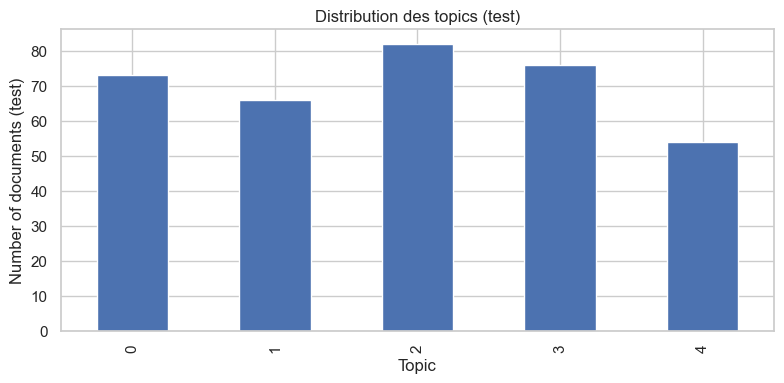

In [23]:
# Afficher les mots top par topic
feature_names = np.array(tfidf.get_feature_names_out())
H = nmf_best.components_  # shape (n_topics, n_features)
n_top_words = 15
topics = []
for topic_idx, topic in enumerate(H):
    top_idx = topic.argsort()[::-1][:n_top_words]
    top_words = feature_names[top_idx].tolist()
    topics.append(top_words)
    print(f'--- Topic {topic_idx} ---')
    print(', '.join(top_words))

# Visualisation distribution topics (test)
import pandas as pd
topic_counts = pd.Series(test_labels).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,4))
topic_counts.plot.bar(ax=ax, color='C0')
ax.set_xlabel('Topic')
ax.set_ylabel('Number of documents (test)')
ax.set_title('Distribution des topics (test)')
plt.tight_layout()
plt.show()